<a href="https://colab.research.google.com/github/meenakshimeenuzz21/DSA-Class-Notes/blob/main/Assessment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**Load Dataset**

In [4]:
train = pd.read_csv("/content/train_LZdllcl.csv")
test = pd.read_csv("/content/test_2umaH9m.csv")
sample = pd.read_csv("/content/sample_submission_M0L0uXE.csv")

In [23]:
train.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,7,31,2,0,2,1,35,5.0,8,1,0,49,0
1,65141,4,14,0,1,0,1,30,5.0,4,0,0,60,0
2,7513,7,10,0,1,2,1,34,3.0,7,0,0,50,0
3,2542,7,15,0,1,0,2,39,1.0,10,0,0,50,0
4,48945,8,18,0,1,0,1,45,3.0,2,0,0,73,0


In [24]:
test.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8724,8,18,0,1,2,1,24,3.0,1,1,0,77
1,74430,2,28,0,0,0,1,31,3.0,5,0,0,51
2,72255,7,4,0,1,0,1,31,1.0,4,0,0,47
3,38562,5,11,0,0,0,3,31,2.0,9,0,0,65
4,64486,1,21,0,1,2,1,30,4.0,7,0,0,61


**Exploratory Data Analysis**

In [25]:
train.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,7,31,2,0,2,1,35,5.0,8,1,0,49,0
1,65141,4,14,0,1,0,1,30,5.0,4,0,0,60,0
2,7513,7,10,0,1,2,1,34,3.0,7,0,0,50,0
3,2542,7,15,0,1,0,2,39,1.0,10,0,0,50,0
4,48945,8,18,0,1,0,1,45,3.0,2,0,0,73,0


In [7]:
print(train.shape)

(54808, 14)


In [8]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB
None


In [31]:
train.describe()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,4.972796,15.428970,0.559316,0.702379,0.868158,1.253011,34.803915,3.304481,5.865512,0.351974,0.023172,63.386750,0.085170
std,22586.581449,2.506046,8.764954,0.889452,0.457216,0.980713,0.609264,7.660169,1.214770,4.265094,0.477590,0.150450,13.371559,0.279137
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000,0.000000
25%,19669.750000,4.000000,11.000000,0.000000,0.000000,0.000000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000,0.000000
50%,39225.500000,5.000000,14.000000,0.000000,1.000000,0.000000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000,0.000000
75%,58730.500000,7.000000,21.000000,2.000000,1.000000,2.000000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000,0.000000
max,78298.000000,8.000000,33.000000,2.000000,1.000000,2.000000,10.000000,60.000000,5.000000,37.000000,1.000000,1.000000,99.000000,1.000000


In [32]:
print(train.isnull().sum())

employee_id             0
department              0
region                  0
education               0
gender                  0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
KPIs_met >80%           0
awards_won?             0
avg_training_score      0
is_promoted             0
dtype: int64


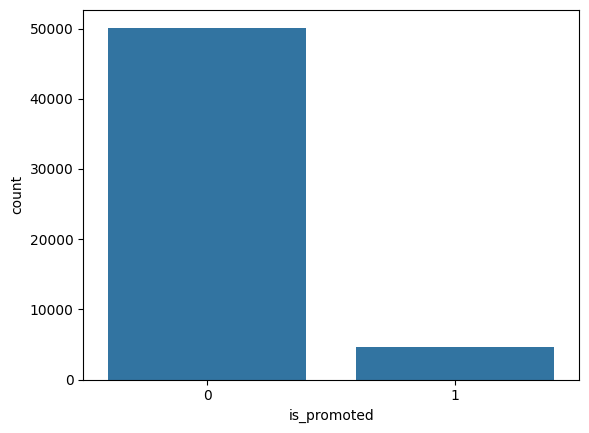

In [43]:
sns.countplot(x='is_promoted', data=train)
plt.show()

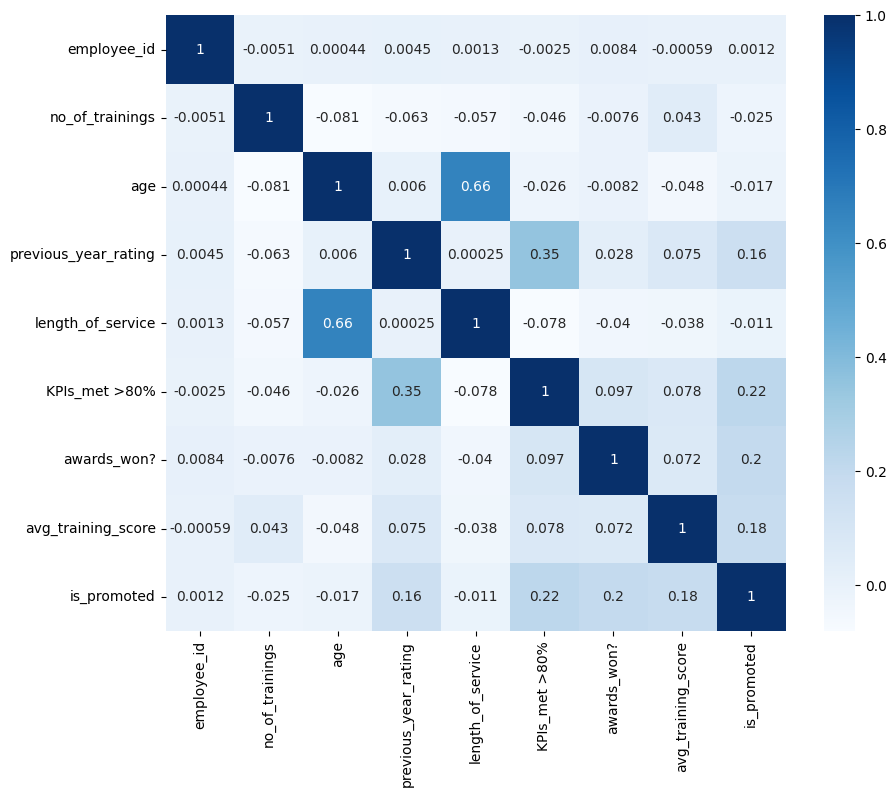

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap="Blues")
plt.show()

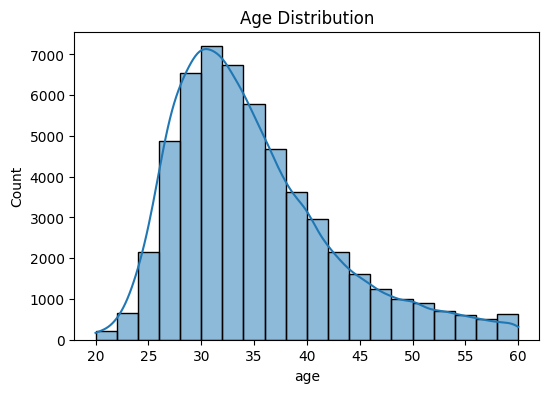

In [33]:
plt.figure(figsize=(6,4))
sns.histplot(train['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

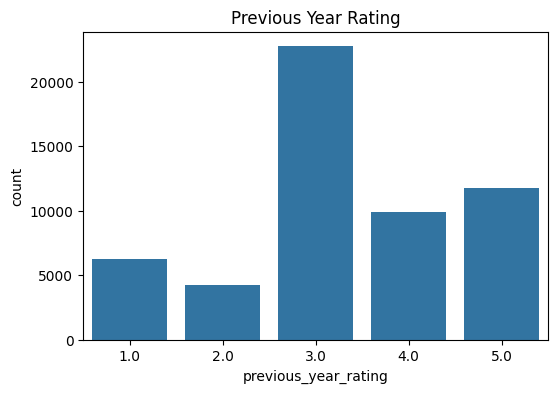

In [34]:
plt.figure(figsize=(6,4))
sns.countplot(x='previous_year_rating', data=train)
plt.title("Previous Year Rating")
plt.show()

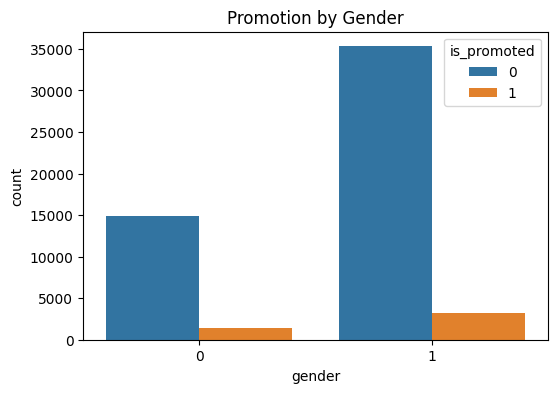

In [35]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='is_promoted', data=train)
plt.title("Promotion by Gender")
plt.show()

**Pre-processing (Train Dataset)**

In [13]:
train["education"] = train["education"].fillna(train["education"].mode()[0])

train["previous_year_rating"] = train["previous_year_rating"].fillna(train["previous_year_rating"].median())

In [14]:
cat_cols = train.select_dtypes(include="object").columns

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))
    label_encoders[col] = le

**Pre-processing (Test Dataset)**

In [15]:
test["education"] = test["education"].fillna(test["education"].mode()[0])

test["previous_year_rating"] = test["previous_year_rating"].fillna(test["previous_year_rating"].median())

In [16]:
for col in cat_cols:
    le = label_encoders[col]
    test[col] = le.transform(test[col].astype(str))

**Split Train Data**

In [17]:
X = train.drop("is_promoted", axis=1)

y = train["is_promoted"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

**Modeling**

In [19]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

pred = rf.predict(X_valid)

print("Accuracy :", accuracy_score(y_valid, pred))

print(classification_report(y_valid, pred))

Accuracy : 0.9358693669038497
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     10054
           1       0.88      0.26      0.40       908

    accuracy                           0.94     10962
   macro avg       0.91      0.63      0.68     10962
weighted avg       0.93      0.94      0.92     10962



In [20]:
from sklearn.metrics import f1_score

In [21]:
f1 = f1_score(y_valid, pred)

print("F1 Score:", f1)

F1 Score: 0.40271877655055227


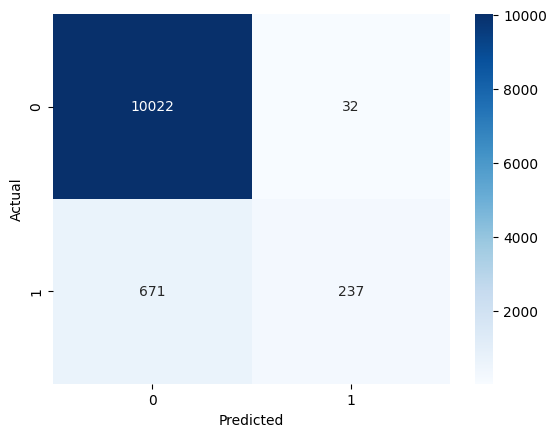

In [22]:
cm = confusion_matrix(y_valid, pred)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [29]:
param_grid = {

    "n_estimators":[100,200],

    "max_depth":[10,20,None],

    "min_samples_split":[2,5]

}

grid = GridSearchCV(

    RandomForestClassifier(random_state=42),

    param_grid,

    cv=3,

    scoring="accuracy",

    n_jobs=-1

)

grid.fit(X_train,y_train)

print(grid.best_params_)

print(grid.best_score_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
0.9317839695404079


In [40]:
best_model = grid.best_estimator_

best_model.fit(X,y)

RandomForestClassifier(n_estimators=200, random_state=42)

In [39]:
test_prediction = best_model.predict(test)

In [41]:
sample["is_promoted"] = test_prediction

sample.to_csv("submission.csv",index=False)

print(sample.head())

   employee_id  is_promoted
0         8724            0
1        74430            0
2        72255            0
3        38562            0
4        64486            0


In [42]:
from google.colab import files

files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>